In [1]:
import glob
import json
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# WHS

In [3]:
FILES = sorted(glob.glob('../results/recon/whs/*.jsonl'))
GROUP_BY = ['run', 'arm', 'view_config', 'anchor', 'temperature', 'placement', 'level_deg'] 
SAMPLE_AGG = 'mean'
STRUCTS = None
DECIMALS = {'dice': 3, 'assd': 2, 'hd95': 2}
STRUCT_ORDER = ['LV', 'MY', 'RV', 'LA', 'RA']

RUN_RENAME = {
    r'.*C.*': 'LC-U-Net-SA',
    r'.*A2c.*':   'LC-U-Net-AA',
    r'.*A2(?!c).*': 'LC-U-Net-AA',
    r'.*A1.*':    'LC-U-Net-A',
    r'.*A0.*':    'LC-U-Net',
    r'.*implicit_poseoff_original.*': 'implicit_poseoff_original',
    r'.*implicit_poseon_canonical.*': 'implicit_poseon_canonical',
    r'.*implicit_poseon_original.*': 'implicit_poseon_original',
}

In [4]:
def _run_label(ckpt):
    import os
    return os.path.splitext(os.path.basename(str(ckpt)))[0]
 
 
def load(files):
    """kind='sample' 行に、そのファイルの meta 行から run 識別列を付与する。
    ckpt / view_config / anchor は sample 行に存在しないため、これをしないと
    「同じ arm の別 checkpoint」が行レベルで区別不能になり黙って混ざる。"""
    samples, metas, skips = [], [], 0
    for path in files:
        meta = {}
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                k = r.get('kind')
                if k == 'meta':
                    meta = r
                    metas.append({'file': path, **{x: r.get(x) for x in
                                  ('model', 'arm', 'anchor', 'view_config',
                                   'placements', 'levels', 'n_samples',
                                   'temperature', 'obs_sigma', 'train_sigma',
                                   'ckpt')}})
                elif k == 'sample' and r.get('dataset') == 'whs':
                    r['_file'] = path
                    r['run'] = _run_label(meta.get('ckpt', path))
                    r['view_config'] = meta.get('view_config')
                    r['anchor'] = meta.get('anchor')
                    r['_ckpt'] = meta.get('ckpt')
                    samples.append(r)
                elif k == 'skip':
                    skips += 1
    if not samples:
        raise SystemExit('no WHS sample rows found (CAMUS rows have no GT metrics)')
    return pd.DataFrame(samples), pd.DataFrame(metas), skips
 
 
raw, metas, n_skip = load(FILES)
print('auto run names:', sorted(raw['run'].dropna().unique()))
 
 
def apply_rename(series, mapping):
    import re as _re
    def one(v):
        if v in mapping:
            return mapping[v]
        for pat, name in mapping.items():
            try:
                if _re.fullmatch(pat, str(v)):
                    return name
            except _re.error:
                pass
        return v
    return series.map(one)
 
 
raw['run'] = apply_rename(raw['run'], RUN_RENAME)
metas['run'] = apply_rename(metas['ckpt'].map(
    lambda c: __import__('os').path.splitext(__import__('os').path.basename(str(c)))[0]),
    RUN_RENAME) if 'ckpt' in metas else metas.get('run')
# リネーム衝突検査: 同じ表示名に複数の ckpt が潰れていないか
if 'ckpt' in metas:
    _c = metas.groupby('run')['ckpt'].nunique()
    _multi = _c[_c > 1]
    for name in _multi.index:
        print(f"note: 表示名 '{name}' は {int(_multi[name])} ckpt を含みます "
              f"(view_config 等の列で分離されていれば問題なし。実際に混在した場合は"
              f"下の混合ガードが '_ckpt' として警告します)")
# float グループ列は数値のまま保持(ソートのため)。表示整形は render_index が担う。
structs = (STRUCTS or
           [s for s in STRUCT_ORDER if f'dice_{s}' in raw.columns
            and raw[f'dice_{s}'].notna().any()])
print(f'{len(raw)} sample rows / {raw.case.nunique()} cases / {n_skip} skips')
print('runs:')
display(metas)

auto run names: ['ad_mc_prior_canon_4000', 'ad_mc_prior_orig_3800', 'lcunet_A0_left_100', 'lcunet_A1_left_150', 'lcunet_A2_left_650', 'lcunet_A2c_left_400', 'lcunet_C_left_450']
note: 表示名 'LC-U-Net-AA' は 2 ckpt を含みます (view_config 等の列で分離されていれば問題なし。実際に混在した場合は下の混合ガードが '_ckpt' として警告します)
2160 sample rows / 120 cases / 0 skips
runs:


,file,model,arm,anchor,view_config,placements,levels,n_samples,temperature,obs_sigma,train_sigma,ckpt,run
0,../results/recon/whs/whs_A0_left_original.jsonl,lcunet,A0,anatomical,left,[original],[0.0],1,1.0,"[8.0, 4.0]","[8.0, 4.0]",./ckpts/A0_left/lcunet_A0_left_100.pth,LC-U-Net
1,../results/recon/whs/whs_A1_left_original.jsonl,lcunet,A1,anatomical,left,[original],[0.0],1,1.0,"[8.0, 4.0]","[8.0, 4.0]",./ckpts/A1_left/lcunet_A1_left_150.pth,LC-U-Net-A
2,../results/recon/whs/whs_A2_left_original.jsonl,lcunet,A2,anatomical,left,[original],[0.0],1,1.0,"[8.0, 4.0]","[8.0, 4.0]",./ckpts/A2_left/lcunet_A2_left_650.pth,LC-U-Net-AA
3,../results/recon/whs/whs_A2c_left_oracle_sweep...,lcunet,A2c,a4c,left,[canonical_oracle],"[0.0, 4.0, 8.0, 12.0, 16.0]",5,1.0,"[8.0, 4.0]","[8.0, 4.0]",./ckpts/A2c_left/lcunet_A2c_left_400.pth,LC-U-Net-AA
4,../results/recon/whs/whs_A2c_left_zero.jsonl,lcunet,A2c,a4c,left,[canonical_zero],[0.0],1,1.0,"[8.0, 4.0]","[8.0, 4.0]",./ckpts/A2c_left/lcunet_A2c_left_400.pth,LC-U-Net-AA
5,../results/recon/whs/whs_C_left_oracle_sweep.j...,lcunet,C,a4c,left,[canonical_oracle],"[0.0, 4.0, 8.0, 12.0, 16.0]",5,1.0,"[8.0, 4.0]","[8.0, 4.0]",./ckpts/C_left/lcunet_C_left_450.pth,LC-U-Net-SA
6,../results/recon/whs/whs_C_left_zero.jsonl,lcunet,C,a4c,left,[canonical_zero],[0.0],1,1.0,"[8.0, 4.0]","[8.0, 4.0]",./ckpts/C_left/lcunet_C_left_450.pth,LC-U-Net-SA
7,../results/recon/whs/whs_implicit_poseoff_orig...,implicit,pose_off,a4c,left,[original],[0.0],1,1.0,"[8.0, 4.0]","[None, None]",./ckpts/prior_orig/ad_mc_prior_orig_3800.pth,ad_mc_prior_orig_3800
8,../results/recon/whs/whs_implicit_poseon_canon...,implicit,pose_on,anatomical,left,[canonical_zero],[0.0],1,1.0,"[8.0, 4.0]","[None, None]",./ckpts/prior_canon/ad_mc_prior_canon_4000.pth,ad_mc_prior_canon_4000
9,../results/recon/whs/whs_implicit_poseon_origi...,implicit,pose_on,a4c,left,[original],[0.0],1,1.0,"[8.0, 4.0]","[None, None]",./ckpts/prior_orig/ad_mc_prior_orig_3800.pth,ad_mc_prior_orig_3800


In [5]:
# --- tidy 化: (group, case, sample_idx, struct) 1 行に -------------------------
def tidy(raw, structs, group_by):
    rows = []
    for _, r in raw.iterrows():
        g = {k: r.get(k) for k in group_by}
        base = {**g, 'case': r['case'], 'sample_idx': r.get('sample_idx', 0),
                'dice_all_row': r.get('dice_all', np.nan),
                'floor': r.get('floor_mean', np.nan)}
        for s in structs:
            d = r.get(f'dice_{s}', np.nan)
            a = r.get(f'assd_{s}', np.nan)
            h = r.get(f'hd95_{s}', np.nan)
            rows.append({**base, 'struct': s, 'dice': d, 'assd': a, 'hd95': h,
                         # pred_empty: dice==0 かつ距離未定義、の指紋で復元
                         'empty': bool(d == 0.0 and not np.isfinite(a))})
    return pd.DataFrame(rows)
 
 
# ---- 混合ガード: GROUP_BY に無いのにグループ内で複数値を持つ判別列を検出 ----
DISCRIMINATORS = ['run', 'view_config', 'anchor', 'temperature', 'level_deg',
                  'placement', 'arm', 'model']
_amb = []
for col in DISCRIMINATORS:
    if col in raw.columns and col not in GROUP_BY:
        nun = raw.groupby(GROUP_BY, dropna=False)[col].nunique(dropna=False)
        bad = nun[nun > 1]
        if len(bad):
            _amb.append((col, bad))
if _amb:
    print('\n*** 警告: 以下の列が GROUP_BY に無いまま同一グループ内で複数値を持ちます。')
    print('*** このままだと異なる条件が 1 行に混ざった mean±std になります。')
    for col, bad in _amb:
        print(f"***   '{col}' -> GROUP_BY に追加を検討。衝突しているグループ:")
        for keys in bad.index[:5]:
            keys_t = keys if isinstance(keys, tuple) else (keys,)
            sel = raw
            for k, v in zip(GROUP_BY, keys_t):
                if pd.isna(v):
                    sel = sel[sel[k].isna()]
                else:
                    sel = sel[sel[k] == v]
            vals = sorted(map(str, sel[col].dropna().unique()))
            gname = ', '.join(f'{k}={v}' for k, v in zip(GROUP_BY, keys_t))
            print(f'***     ({gname}) に {col}={vals} が混在')
        if len(bad) > 5:
            print(f'***     ... 他 {len(bad) - 5} グループ')
else:
    print('mixing guard: ok (グループ内はすべて単一条件)')
 
df = tidy(raw, structs, GROUP_BY)
 
# --- サンプル内集約 ------------------------------------------------------------
def _nanmean_safe(v):
    a = np.asarray(v, float)
    a = a[np.isfinite(a)]
    return a.mean() if a.size else np.nan
 
 
def collapse_samples(df, how, group_by):
    keys = group_by + ['case']
    if how == 'first':
        return df[df['sample_idx'] == 0].copy()
    if how == 'best':
        # dice_all 最大のサンプルを (group, case) ごとに 1 つ選び、その全構造行を使う
        pick = (df.groupby(keys + ['sample_idx'])['dice_all_row'].first()
                  .reset_index()
                  .sort_values('dice_all_row')
                  .groupby(keys, dropna=False).tail(1)[keys + ['sample_idx']])
        return df.merge(pick, on=keys + ['sample_idx'])
    # 'mean': 構造ごとにサンプル平均(距離は nan スキップ、empty は率に)
    agg = (df.groupby(keys + ['struct'], dropna=False)
             .agg(dice=('dice', 'mean'), assd=('assd', _nanmean_safe),
                  hd95=('hd95', _nanmean_safe),
                  empty=('empty', 'mean'), floor=('floor', 'first'))
             .reset_index())
    return agg
 
 
cc = collapse_samples(df, SAMPLE_AGG, GROUP_BY)
print(f'sample aggregation = {SAMPLE_AGG}: {len(cc)} (group,case,struct) rows')

mixing guard: ok (グループ内はすべて単一条件)


sample aggregation = mean: 10800 (group,case,struct) rows


In [6]:
def drop_constant_levels(t):
    """全行で単一値のインデックスレベルを畳み、注記として返す。"""
    notes = []
    for name in list(t.index.names):
        vals = t.index.get_level_values(name).unique()
        if len(vals) == 1 and t.index.nlevels > 1:
            notes.append(f'{name}={vals[0]}')
            t = t.droplevel(name)
    return t, notes
 
 
def fmt(v, nd):
    v = np.asarray(v, float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return '—'
    if v.size == 1:
        return f'{v[0]:.{nd}f}'
    return f'{v.mean():.{nd}f} ± {v.std(ddof=1):.{nd}f}'
 
 
def agg_table(cc, metric, group_by, structs, nd):
    out = {}
    for keys, g in cc.groupby(group_by, dropna=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        row = {s: fmt(g.loc[g['struct'] == s, metric], nd) for s in structs}
        per_case = (g.pivot_table(index='case', columns='struct', values=metric)
                      .reindex(columns=structs).mean(axis=1, skipna=True))
        row['Mean'] = fmt(per_case, nd)
        row['n'] = g['case'].nunique()
        row['empty%'] = f"{100 * g['empty'].mean():.1f}" if 'empty' in g else '—'
        row['floor'] = fmt(g.groupby('case')['floor'].first(), 3)
        out[keys] = row
    t = pd.DataFrame(out).T
    t.index.names = group_by
    return t[structs + ['Mean', 'n', 'empty%', 'floor']].sort_index()
 
 
tables = {'Dice ↑': agg_table(cc, 'dice', GROUP_BY, structs, DECIMALS['dice']),
          'ASSD (mm) ↓': agg_table(cc, 'assd', GROUP_BY, structs, DECIMALS['assd']),
          'HD95 (mm) ↓': agg_table(cc, 'hd95', GROUP_BY, structs, DECIMALS['hd95'])}
_notes = None
for title in list(tables):
    tables[title], _notes = drop_constant_levels(tables[title])
if _notes:
    print('constant (folded out of the index): ' + ', '.join(_notes))
for title, t in tables.items():
    print(f'\n== {title}  (sample agg: {SAMPLE_AGG}) ==')
    display(t)

constant (folded out of the index): view_config=left, temperature=1.0

== Dice ↑  (sample agg: mean) ==


LV  \
run                    arm      anchor     placement        level_deg                  
LC-U-Net               A0       anatomical original         0.0        0.902 ± 0.083   
LC-U-Net-A             A1       anatomical original         0.0        0.962 ± 0.011   
LC-U-Net-AA            A2       anatomical original         0.0        0.936 ± 0.020   
                       A2c      a4c        canonical_oracle 0.0        0.930 ± 0.023   
                                                            4.0        0.929 ± 0.024   
                                                            8.0        0.925 ± 0.026   
                                                            12.0       0.919 ± 0.029   
                                                            16.0       0.913 ± 0.033   
                                           canonical_zero   0.0        0.909 ± 0.088   
LC-U-Net-SA            C        a4c        canonical_oracle 0.0        0.952 ± 0.012   
                                                            4.0        0.882 ± 0.054   
                                                            8.0        0.798 ± 0.099   
                                                            12.0       0.736 ± 0.119   
                                                            16.0       0.696 ± 0.124   
                                           canonical_zero   0.0        0.713 ± 0.164   
ad_mc_prior_canon_4000 pose_on  anatomical canonical_zero   0.0        0.798 ± 0.088   
ad_mc_prior_orig_3800  pose_off a4c        original         0.0        0.949 ± 0.015   
                       pose_on  a4c        original         0.0        0.941 ± 0.015   

                                                                                  MY  \
run                    arm      anchor     placement        level_deg                  
LC-U-Net               A0       anatomical original         0.0        0.820 ± 0.120   
LC-U-Net-A             A1       anatomical original         0.0        0.922 ± 0.019   
LC-U-Net-AA            A2       anatomical original         0.0        0.870 ± 0.042   
                       A2c      a4c        canonical_oracle 0.0        0.853 ± 0.050   
                                                            4.0        0.850 ± 0.052   
                                                            8.0        0.841 ± 0.055   
                                                            12.0       0.828 ± 0.064   
                                                            16.0       0.813 ± 0.075   
                                           canonical_zero   0.0        0.820 ± 0.103   
LC-U-Net-SA            C        a4c        canonical_oracle 0.0        0.898 ± 0.023   
                                                            4.0        0.739 ± 0.121   
                                                            8.0        0.583 ± 0.169   
                                                            12.0       0.500 ± 0.169   
                                                            16.0       0.471 ± 0.158   
                                           canonical_zero   0.0        0.528 ± 0.200   
ad_mc_prior_canon_4000 pose_on  anatomical canonical_zero   0.0        0.623 ± 0.141   
ad_mc_prior_orig_3800  pose_off a4c        original         0.0        0.884 ± 0.031   
                       pose_on  a4c        original         0.0        0.870 ± 0.033   

                                                                                  RV  \
run                    arm      anchor     placement        level_deg                  
LC-U-Net               A0       anatomical original         0.0        0.834 ± 0.066   
LC-U-Net-A             A1       anatomical original         0.0        0.889 ± 0.034   
LC-U-Net-AA            A2       anatomical original         0.0        0.883 ± 0.038   
                       A2c      a4c        canonical_oracle 0.0        0.849 ± 0.049   
                                


== ASSD (mm) ↓  (sample agg: mean) ==


LV  \
run                    arm      anchor     placement        level_deg                
LC-U-Net               A0       anatomical original         0.0        2.03 ± 1.93   
LC-U-Net-A             A1       anatomical original         0.0        0.78 ± 0.20   
LC-U-Net-AA            A2       anatomical original         0.0        1.28 ± 0.35   
                       A2c      a4c        canonical_oracle 0.0        1.35 ± 0.39   
                                                            4.0        1.37 ± 0.40   
                                                            8.0        1.44 ± 0.42   
                                                            12.0       1.53 ± 0.48   
                                                            16.0       1.65 ± 0.55   
                                           canonical_zero   0.0        1.78 ± 2.08   
LC-U-Net-SA            C        a4c        canonical_oracle 0.0        0.95 ± 0.20   
                                                            4.0        2.21 ± 0.97   
                                                            8.0        3.82 ± 2.00   
                                                            12.0       5.24 ± 2.66   
                                                            16.0       6.39 ± 2.99   
                                           canonical_zero   0.0        5.19 ± 3.20   
ad_mc_prior_canon_4000 pose_on  anatomical canonical_zero   0.0        3.62 ± 1.50   
ad_mc_prior_orig_3800  pose_off a4c        original         0.0        1.03 ± 0.28   
                       pose_on  a4c        original         0.0        1.19 ± 0.28   

                                                                                MY  \
run                    arm      anchor     placement        level_deg                
LC-U-Net               A0       anatomical original         0.0        1.57 ± 1.05   
LC-U-Net-A             A1       anatomical original         0.0        0.77 ± 0.18   
LC-U-Net-AA            A2       anatomical original         0.0        1.21 ± 0.29   
                       A2c      a4c        canonical_oracle 0.0        1.30 ± 0.34   
                                                            4.0        1.32 ± 0.35   
                                                            8.0        1.38 ± 0.37   
                                                            12.0       1.46 ± 0.40   
                                                            16.0       1.55 ± 0.44   
                                           canonical_zero   0.0        1.61 ± 1.40   
LC-U-Net-SA            C        a4c        canonical_oracle 0.0        0.94 ± 0.18   
                                                            4.0        1.96 ± 0.68   
                                                            8.0        3.12 ± 1.54   
                                                            12.0       4.18 ± 2.11   
                                                            16.0       4.98 ± 2.36   
                                           canonical_zero   0.0        3.96 ± 2.31   
ad_mc_prior_canon_4000 pose_on  anatomical canonical_zero   0.0        2.79 ± 0.85   
ad_mc_prior_orig_3800  pose_off a4c        original         0.0        1.10 ± 0.22   
                       pose_on  a4c        original         0.0        1.21 ± 0.23   

                                                                                RV  \
run                    arm      anchor     placement        level_deg                
LC-U-Net               A0       anatomical original         0.0        3.57 ± 2.03   
LC-U-Net-A             A1       anatomical original         0.0        1.97 ± 0.55   
LC-U-Net-AA            A2       anatomical original         0.0        2.07 ± 0.63   
                       A2c      a4c        canonical_oracle 0.0        2.58 ± 0.77   
                                                            4.0        2.59 ± 0.78   
                                    


== HD95 (mm) ↓  (sample agg: mean) ==


LV  \
run                    arm      anchor     placement        level_deg                  
LC-U-Net               A0       anatomical original         0.0         7.47 ± 11.21   
LC-U-Net-A             A1       anatomical original         0.0          2.33 ± 0.65   
LC-U-Net-AA            A2       anatomical original         0.0          3.07 ± 0.80   
                       A2c      a4c        canonical_oracle 0.0          3.49 ± 1.20   
                                                            4.0          3.51 ± 1.21   
                                                            8.0          3.70 ± 1.24   
                                                            12.0         3.98 ± 1.35   
                                                            16.0         4.30 ± 1.49   
                                           canonical_zero   0.0          4.59 ± 5.36   
LC-U-Net-SA            C        a4c        canonical_oracle 0.0          2.52 ± 0.78   
                                                            4.0          5.80 ± 2.61   
                                                            8.0         10.64 ± 5.36   
                                                            12.0        15.81 ± 8.31   
                                                            16.0       21.21 ± 11.14   
                                           canonical_zero   0.0         14.43 ± 8.38   
ad_mc_prior_canon_4000 pose_on  anatomical canonical_zero   0.0          8.87 ± 4.01   
ad_mc_prior_orig_3800  pose_off a4c        original         0.0          3.05 ± 1.10   
                       pose_on  a4c        original         0.0          3.27 ± 1.07   

                                                                                 MY  \
run                    arm      anchor     placement        level_deg                 
LC-U-Net               A0       anatomical original         0.0         5.16 ± 4.14   
LC-U-Net-A             A1       anatomical original         0.0         2.23 ± 0.51   
LC-U-Net-AA            A2       anatomical original         0.0         2.81 ± 0.70   
                       A2c      a4c        canonical_oracle 0.0         3.27 ± 1.03   
                                                            4.0         3.30 ± 1.07   
                                                            8.0         3.49 ± 1.11   
                                                            12.0        3.73 ± 1.28   
                                                            16.0        4.04 ± 1.47   
                                           canonical_zero   0.0         4.19 ± 4.52   
LC-U-Net-SA            C        a4c        canonical_oracle 0.0         2.43 ± 0.67   
                                                            4.0         5.23 ± 2.25   
                                                            8.0         9.38 ± 4.85   
                                                            12.0       13.69 ± 7.19   
                                                            16.0       17.99 ± 9.51   
                                           canonical_zero   0.0        11.99 ± 6.91   
ad_mc_prior_canon_4000 pose_on  anatomical canonical_zero   0.0         7.52 ± 2.87   
ad_mc_prior_orig_3800  pose_off a4c        original         0.0         2.96 ± 0.85   
                       pose_on  a4c        original         0.0         3.12 ± 0.85   

                                                                                  RV  \
run                    arm      anchor     placement        level_deg                  
LC-U-Net               A0       anatomical original         0.0        17.01 ± 17.99   
LC-U-Net-A             A1       anatomical original         0.0          5.83 ± 2.58   
LC-U-Net-AA            A2       anatomical original         0.0          5.74 ± 2.57   
                       A2c      a4c        canonical_oracle 0.0          7.08 ± 2.85   
                                                    

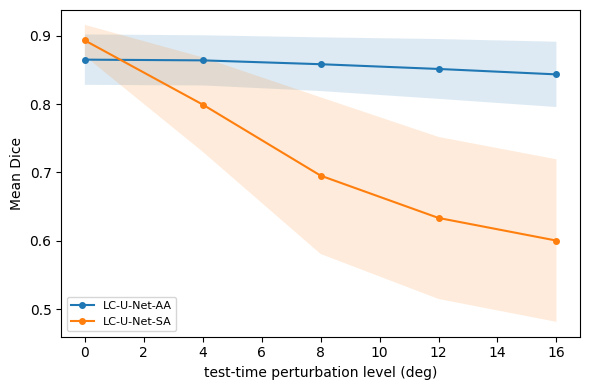

,level_deg,0.0,4.0,8.0,12.0,16.0
run,arm,,,,,
LC-U-Net-AA,A2c,0.865 ± 0.037,0.864 ± 0.037,0.858 ± 0.039,0.851 ± 0.044,0.844 ± 0.048
LC-U-Net-SA,C,0.893 ± 0.023,0.799 ± 0.069,0.695 ± 0.115,0.633 ± 0.119,0.600 ± 0.119


In [7]:
# CURVE_PLACEMENTS = ['original', 'canonical_oracle']   # placement ごとに別パネル
CURVE_PLACEMENTS = ['canonical_oracle']   # placement ごとに別パネル
CURVE_DROP = {'view_config': ['whole']}               # カーブから除外する条件
CURVE_LABEL_EXCLUDE = {'view_config', 'arm'}                 # 凡例に載せない列
CURVE_BAND = 'std'                                    # 'std' | 'sem' | None
 
def curve_data(cc, group_by):
    """(group, level) ごとの症例平均 Mean-Dice の mean±std。"""
    pc = (cc.pivot_table(index=group_by + ['case'], columns='struct',
                         values='dice')
            .reindex(columns=structs).mean(axis=1, skipna=True)
            .rename('mean_dice').reset_index())
    return pc
 
_pc = curve_data(cc, GROUP_BY)
for _col, _vals in CURVE_DROP.items():
    if _col in _pc.columns:
        _pc = _pc[~_pc[_col].isin(_vals)]
_pc = _pc[_pc['placement'].isin(CURVE_PLACEMENTS)]
 
# 凡例: run + 「実際に複数値を持つ列」(placement はパネル題、除外列は載せない)
line_keys = [c for c in GROUP_BY if c not in ('level_deg', 'placement')]
_varying = {c for c in line_keys if _pc[c].nunique(dropna=False) > 1}
_label_cols = sorted(({'run'} | _varying) - set(CURVE_LABEL_EXCLUDE),
                     key=lambda c: line_keys.index(c))
 
fig, axes = plt.subplots(1, len(CURVE_PLACEMENTS),
                         figsize=(6 * len(CURVE_PLACEMENTS), 4.0),
                         sharey=True, squeeze=False)
for ax, pl in zip(axes[0], CURVE_PLACEMENTS):
    sub = _pc[_pc['placement'] == pl]
    for keys, g in sub.groupby(line_keys, dropna=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        _parts = [str(v) for k, v in zip(line_keys, keys)
                  if k in _label_cols and pd.notna(v)]
        lab = ' / '.join(dict.fromkeys(_parts))   # 同値の重複(run==arm 等)を除去
        st = g.groupby('level_deg')['mean_dice'].agg(['mean', 'std', 'count']).sort_index()
        ax.plot(st.index, st['mean'], marker='o', ms=4, label=lab)
        if CURVE_BAND:
            half = st['std'] if CURVE_BAND == 'std' else st['std'] / np.sqrt(st['count'])
            ax.fill_between(st.index, st['mean'] - half, st['mean'] + half, alpha=0.15)
    ax.set(xlabel='test-time perturbation level (deg)')
    ax.legend(fontsize=8)
axes[0, 0].set_ylabel('Mean Dice')
fig.tight_layout()
plt.show()
 
# 数値も表で(level を列に展開)
_curve_tbl = (_pc.groupby(line_keys + ['level_deg'])['mean_dice']
                 .agg(['mean', 'std'])
                 .apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)
                 .unstack('level_deg'))
display(drop_constant_levels(_curve_tbl)[0])

== load_z 診断(z が 0 のファイルは placement を確認: original は z を持たない仕様、canonical_* だけが持つ)==


,file,sample_rows,rows_with_z,datasets,placements
0,C_canonical_posterior_s8_T1.jsonl,960,960,[whs],[canonical_posterior]
1,camus_C_post_T1_gt.jsonl,2400,2400,[camus],[canonical_posterior]


dataset  run        
camus    LC-U-Net-SA    2400
whs      LC-U-Net-SA     960
Name: n_z_rows, dtype: int64


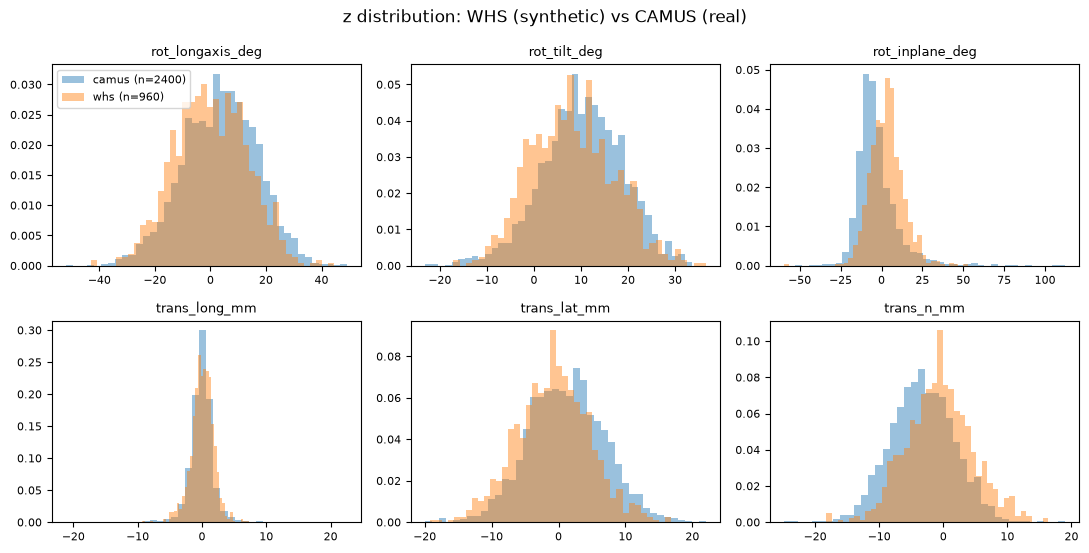

,camus mean,camus std,whs mean,whs std,CAMUS outside WHS p1-p99
dim,,,,,
rot_longaxis_deg,+3.44,13.44,+0.17,13.02,4.1%
rot_tilt_deg,+10.28,8.66,+8.15,8.82,2.3%
rot_inplane_deg,-2.78,12.65,+3.24,10.13,6.6%
trans_long_mm,-0.01,2.03,+0.06,1.76,3.2%
trans_lat_mm,+1.20,5.73,-0.81,5.46,3.7%
trans_n_mm,-3.26,4.95,-0.57,5.21,2.6%


In [95]:
Z_FILES = [
    '../results/recon/whs/C_canonical_posterior_s8_T1.jsonl',
    '../results/recon/camus/camus_C_post_T1_gt.jsonl',
]
# 「学習支持域チェック」をしたい場合は WHS 側を oracle(z* = 教師分布)に:
# Z_FILES[0] = './results/recon/whs/C_canonical_oracle_s8.jsonl'
Z_NAMES6 = ['rot_longaxis_deg', 'rot_tilt_deg', 'rot_inplane_deg',
            'trans_long_mm', 'trans_lat_mm', 'trans_n_mm']
Z_RUN_FILTER = None      # 例: 'C' — 特定 run のみ比較したいとき
 
def load_z(files):
    rows, report = [], []
    for path in files:
        meta = {}
        n_samp = n_z = 0
        dsets, placements = set(), set()
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                if r.get('kind') == 'meta':
                    meta = r
                elif r.get('kind') == 'sample':
                    n_samp += 1
                    dsets.add(str(r.get('dataset')))
                    placements.add(str(r.get('placement')))
                    z = r.get('z')
                    if isinstance(z, list) and len(z) >= len(Z_NAMES6):
                        n_z += 1
                        rows.append({'dataset': r.get('dataset') or 'unknown',
                                     'run': _run_label(meta.get('ckpt', path)),
                                     'placement': r.get('placement'),
                                     'level_deg': r.get('level_deg'),
                                     'temperature': meta.get('temperature'),
                                     **{n_: v for n_, v in zip(Z_NAMES6, z)}})
        report.append({'file': os.path.basename(path), 'sample_rows': n_samp,
                       'rows_with_z': n_z, 'datasets': sorted(dsets),
                       'placements': sorted(placements)})
    print('== load_z 診断(z が 0 のファイルは placement を確認: original は z を'
          '持たない仕様、canonical_* だけが持つ)==')
    display(pd.DataFrame(report))
    return pd.DataFrame(rows)
 
 
zdf = load_z(Z_FILES)
if not len(zdf):
    raise SystemExit('z 行がありません: Z_FILES のパスと上の診断表を確認')
zdf['run'] = apply_rename(zdf['run'], RUN_RENAME)
if Z_RUN_FILTER:
    zdf = zdf[zdf['run'] == Z_RUN_FILTER]
# level>0 の WHS 行は z に摂動が注入されている(perturb_z)ので分布比較から除外
if 'level_deg' in zdf.columns:
    _n0 = len(zdf)
    zdf = zdf[(zdf['dataset'] != 'whs') | (zdf['level_deg'].fillna(0) == 0)]
    if len(zdf) < _n0:
        print(f'level>0 の WHS z 行を {_n0 - len(zdf)} 行除外(摂動注入済みのため)')
print(zdf.groupby(['dataset', 'run']).size().rename('n_z_rows'))
 
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6))
for ax, name in zip(axes.ravel(), Z_NAMES6):
    for ds, g in zdf.groupby('dataset'):
        v = g[name].dropna()
        if not len(v):
            continue
        ax.hist(v, bins=40, density=True, alpha=0.45, label=f'{ds} (n={len(v)})')
    ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=8)
axes[0, 0].legend(fontsize=8)
fig.suptitle('z distribution: WHS (synthetic) vs CAMUS (real)')
fig.tight_layout()
plt.show()
 
# 要約統計(mean/std/p5/p95)と、WHS の p1-p99 支持域から出た CAMUS 割合
stats_rows = []
for name in Z_NAMES6:
    row = {'dim': name}
    for ds, g in zdf.groupby('dataset'):
        v = g[name].dropna()
        if len(v):
            row[f'{ds} mean'] = f'{v.mean():+.2f}'
            row[f'{ds} std'] = f'{v.std(ddof=1):.2f}'
    w = zdf.loc[zdf.dataset == 'whs', name].dropna()
    c = zdf.loc[zdf.dataset == 'camus', name].dropna()
    if len(w) > 10 and len(c):
        lo, hi = np.percentile(w, [1, 99])
        row['CAMUS outside WHS p1-p99'] = f'{100 * ((c < lo) | (c > hi)).mean():.1f}%'
    stats_rows.append(row)
display(pd.DataFrame(stats_rows).set_index('dim'))

# CAMUS

In [ ]:
import glob
import itertools
import json
import os
import re
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score
from scipy import stats

In [ ]:
FILES = sorted(glob.glob('../results/recon/camus/*.jsonl'))
LABELS_PATTERNS = {'gt': r'_gt', 'pred': r'_pred'}
EF_CLASSES = [
    (0, 40, 'Reduced'),
    (40, 50, 'Mid-range'),
    (50, 100, 'Preserved'),
]

In [ ]:
RUN_RENAME = {
    r'.*C_a4c.*_T1$': 'LC-U-Net-SA (T=1)',
    r'.*C_a4c.*_T0$': 'LC-U-Net-SA (T=0)',
    r'.*A2c.*':       'LC-U-Net-AA',
    r'.*ad.*':  'Implicit (pose on)',
}
LABEL_RENAME = {'gt': 'GT 2D', 'pred': 'Pred 2D'}
MODEL_ORDER = ['LC-U-Net-SA (T=1)', 'LC-U-Net-SA (T=0)', 'LC-U-Net-AA', 'Implicit (pose on)']

In [ ]:
def _label_source(meta, path):
    name = os.path.basename(path)
    for label, pat in LABELS_PATTERNS.items():
        if re.search(pat, name):
            return label
    # フォールバック: meta の camus_dir
    d = str(meta.get('args', {}).get('camus_dir', ''))
    if 'pred' in d:
        return 'pred'
    if re.search(r'(^|[/_])gt([/_]|$)', d):
        return 'gt'
    return '?'
 
 
def _run_label(meta, path):
    ck = meta.get('ckpt') or meta.get('model') or path
    base = os.path.splitext(os.path.basename(str(ck)))[0]
    t = meta.get('temperature')
    return f'{base}_T{t:g}' if t is not None else base
 
 
def load(files):
    rows, metas = [], []
    for path in files:
        meta = {}
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                if r.get('kind') == 'meta':
                    meta = r
                    metas.append({'file': path, 'run': _run_label(r, path),
                                  'labels': _label_source(r, path),
                                  **{x: r.get(x) for x in
                                     ('model', 'arm', 'anchor', 'view_config',
                                      'temperature', 'n_samples', 'ckpt')}})
                elif r.get('kind') == 'case' and r.get('dataset', 'camus') == 'camus':
                    rows.append({'run': _run_label(meta, path),
                                 'labels': _label_source(meta, path),
                                 'model': meta.get('model'), 'arm': meta.get('arm'),
                                 'temperature': meta.get('temperature'),
                                 'n_samples': meta.get('n_samples'), **r})
    df = pd.DataFrame(rows)
    if df.empty:
        raise SystemExit('no CAMUS case rows found')
    need = ['ef_median', 'ef_ref']
    df = df.dropna(subset=[c for c in need if c in df.columns])
    df['ef_err'] = df['ef_median'] - df['ef_ref']       # 符号付き(予測 − 参照)
    return df, pd.DataFrame(metas)
 
 
df, metas = load(FILES)
print('auto run names:', sorted(df['run'].unique()))
 
 
def apply_rename(series, mapping):
    def one(v):
        if v in mapping:                      # 完全一致
            return mapping[v]
        for pat, name in mapping.items():     # 正規表現
            try:
                if re.fullmatch(pat, str(v)):
                    return name
            except re.error:
                pass
        return v                              # 未対応はそのまま(混ざらない)
    return series.map(one)
 
 
df['run'] = apply_rename(df['run'], RUN_RENAME)
df['labels'] = apply_rename(df['labels'], LABEL_RENAME)
metas['run'] = apply_rename(metas['run'], RUN_RENAME)
metas['labels'] = apply_rename(metas['labels'], LABEL_RENAME)
_dup = df.groupby(['run', 'labels'])['file' if 'file' in df else 'case'].size() if False else None
runs = MODEL_ORDER or sorted(df['run'].unique())
print(f'{len(df)} case rows, runs={runs}, labels={sorted(df.labels.unique())}')
display(metas)
 
# リネームで別 run が同名に潰れていないかの検査(症例の重複で検出)
_chk = df.groupby(['run', 'labels'])['case'].agg(['size', 'nunique'])
_col = _chk[_chk['size'] > _chk['nunique']]
if len(_col):
    print('*** 警告: 以下の (run, labels) で症例が重複 = 別 run が同じ表示名に潰れています')
    display(_col)

auto run names: ['ad_mc_echo6_canon_4000_T1', 'lcunet_A2c_s8_400_T1', 'lcunet_C_a4c_s8_400_T0', 'lcunet_C_a4c_s8_400_T1']
1200 case rows, runs=['LC-U-Net-SA (T=1)', 'LC-U-Net-SA (T=0)', 'LC-U-Net-AA', 'Implicit (pose on)'], labels=['GT 2D', 'Pred 2D']


,file,run,labels,model,arm,anchor,view_config,temperature,n_samples,ckpt
0,../results/recon/camus/camus_A2c_zero_gt.jsonl,LC-U-Net-AA,GT 2D,lcunet,A2c,a4c,left,1.0,1,ckpts/A2c_s8/lcunet_A2c_s8_400.pth
1,../results/recon/camus/camus_A2c_zero_pred.jsonl,LC-U-Net-AA,Pred 2D,lcunet,A2c,a4c,left,1.0,1,ckpts/A2c_s8/lcunet_A2c_s8_400.pth
2,../results/recon/camus/camus_C_post_T0_gt.jsonl,LC-U-Net-SA (T=0),GT 2D,lcunet,C,a4c,left,0.0,1,ckpts/C_a4c_s8/lcunet_C_a4c_s8_400.pth
3,../results/recon/camus/camus_C_post_T0_pred.jsonl,LC-U-Net-SA (T=0),Pred 2D,lcunet,C,a4c,left,0.0,1,ckpts/C_a4c_s8/lcunet_C_a4c_s8_400.pth
4,../results/recon/camus/camus_C_post_T1_gt.jsonl,LC-U-Net-SA (T=1),GT 2D,lcunet,C,a4c,left,1.0,8,ckpts/C_a4c_s8/lcunet_C_a4c_s8_400.pth
5,../results/recon/camus/camus_C_post_T1_pred.jsonl,LC-U-Net-SA (T=1),Pred 2D,lcunet,C,a4c,left,1.0,8,ckpts/C_a4c_s8/lcunet_C_a4c_s8_400.pth
6,../results/recon/camus/camus_implicit_poseon_z...,Implicit (pose on),GT 2D,implicit,pose_on,a4c,left,1.0,1,ckpts/prior_canon/ad_mc_echo6_canon_4000.pth
7,../results/recon/camus/camus_implicit_poseon_z...,Implicit (pose on),Pred 2D,implicit,pose_on,a4c,left,1.0,1,ckpts/prior_canon/ad_mc_echo6_canon_4000.pth


In [ ]:
def ef_class(v):
    for lo, hi, name in EF_CLASSES:
        if lo < v <= hi if np.isfinite(hi) else lo < v:
            return name
    return EF_CLASSES[-1][2]
 
 
def kappa(a, b, labels):
    idx = {c: i for i, c in enumerate(labels)}
    m = np.zeros((len(labels), len(labels)))
    for x, y in zip(a, b):
        m[idx[x], idx[y]] += 1
    n = m.sum()
    po = np.trace(m) / n
    pe = (m.sum(0) * m.sum(1)).sum() / n ** 2
    return (po - pe) / (1 - pe) if pe < 1 else np.nan, m
 
 
def ccc(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    mx, my = x.mean(), y.mean()
    sxy = ((x - mx) * (y - my)).mean()
    return 2 * sxy / (x.var() + y.var() + (mx - my) ** 2)
 
 
def summary_table(df, group_cols=('run', 'labels')):
    out = {}
    for keys, g in df.groupby(list(group_cols), dropna=False):
        e = g['ef_err'].to_numpy(float)
        p, r_ = g['ef_median'].to_numpy(float), g['ef_ref'].to_numpy(float)
        row = {'n': len(g),
               'bias': f'{e.mean():+.2f}',
               'MAE': f'{np.abs(e).mean():.2f}',
               'RMSE': f'{np.sqrt((e**2).mean()):.2f}',
               'r': f'{stats.pearsonr(p, r_)[0]:.3f}' if len(g) > 2 else '—',
               'rho': f'{stats.spearmanr(p, r_)[0]:.3f}' if len(g) > 2 else '—',
               'CCC': f'{ccc(p, r_):.3f}' if len(g) > 2 else '—',
               'LoA': f'[{e.mean()-1.96*e.std(ddof=1):+.1f}, '
                      f'{e.mean()+1.96*e.std(ddof=1):+.1f}]'}
        if 'ef_covered' in g and g['ef_covered'].notna().any() and g['ef_width'].max() > 0:
            row['cover'] = f"{g['ef_covered'].mean():.2f}"
            row['width'] = f"{g['ef_width'].mean():.1f}"
        else:
            row['cover'], row['width'] = '—', '—'
        out[keys] = row
    t = pd.DataFrame(out).T
    t.index.names = list(group_cols)
    return t
 
tbl = summary_table(df)
print('== T1: EF agreement ==')
display(tbl)

== T1: EF agreement ==


n    bias    MAE   RMSE      r    rho    CCC  \
run                labels                                                    
Implicit (pose on) GT 2D    150   +1.49   6.43   8.13  0.799  0.783  0.791   
                   Pred 2D  150   +1.76   8.61  12.89  0.604  0.707  0.579   
LC-U-Net-AA        GT 2D    150  -16.01  16.79  20.12  0.381  0.330  0.178   
                   Pred 2D  150  -15.19  16.14  20.22  0.377  0.325  0.209   
LC-U-Net-SA (T=0)  GT 2D    150   +0.07   6.49   8.71  0.814  0.845  0.795   
                   Pred 2D  150   +0.05   9.66  12.69  0.631  0.659  0.605   
LC-U-Net-SA (T=1)  GT 2D    150   -1.38   6.83   8.70  0.791  0.816  0.778   
                   Pred 2D  150   -1.12   8.92  11.93  0.630  0.655  0.614   

                                       LoA cover width  
run                labels                               
Implicit (pose on) GT 2D    [-14.2, +17.2]     —     —  
                   Pred 2D  [-23.3, +26.9]     —     —  
LC-U-Net-AA        GT 2D     [-40.0, +7.9]     —     —  
                   Pred 2D  [-41.4, +11.0]     —     —  
LC-U-Net-SA (T=0)  GT 2D    [-17.1, +17.2]     —     —  
                   Pred 2D  [-24.9, +25.0]     —     —  
LC-U-Net-SA (T=1)  GT 2D    [-18.3, +15.5]  0.89  35.3  
                   Pred 2D  [-24.5, +22.2]  0.80  34.5

In [ ]:
def ef_to_class(x):
    if 0 <= x <= 40:
        return EF_CLASSES[0][2]
    elif 40 < x < 50:
        return EF_CLASSES[1][2]
    elif 50 <= x <= 100:
        return EF_CLASSES[2][2]
    return np.nan


def summary_table(df, group_cols=('run', 'labels')):
    out = {}
    confusion_matrices = {}

    cls_names = [c[2] for c in EF_CLASSES]

    for keys, g in df.groupby(list(group_cols), dropna=False):

        # Predicted EF and reference EF
        p = g['ef_median'].to_numpy(float)
        r = g['ef_ref'].to_numpy(float)

        # EF -> class
        p_cls = np.array([ef_to_class(x) for x in p])
        r_cls = np.array([ef_to_class(x) for x in r])

        # Remove invalid values
        valid = pd.notna(p_cls) & pd.notna(r_cls)
        p_cls = p_cls[valid]
        r_cls = r_cls[valid]

        row = {}

        # Overall accuracy
        row['accuracy'] = accuracy_score(r_cls, p_cls)

        # Recall for each class
        recalls = recall_score(
            r_cls,
            p_cls,
            labels=cls_names,
            average=None,
            zero_division=0
        )

        for cls, recall in zip(cls_names, recalls):
            row[f'recall_{cls}'] = recall

        out[keys] = row

        # Confusion matrix
        cm = confusion_matrix(
            r_cls,
            p_cls,
            labels=cls_names
        )

        confusion_matrices[keys] = pd.DataFrame(
            cm,
            index=[f'True {c}' for c in cls_names],
            columns=[f'Pred {c}' for c in cls_names]
        )

    summary = pd.DataFrame(out).T
    summary.index.names = list(group_cols)

    return summary, confusion_matrices


# Run
summary, cms = summary_table(df)

print('== EF classification performance ==')
display(summary)

for key, cm in cms.items():
    print(f'\n{key}')
    display(cm)

== EF classification performance ==


accuracy  recall_Reduced  recall_Mid-range  \
run                labels                                                
Implicit (pose on) GT 2D    0.660000            0.68          0.479167   
                   Pred 2D  0.586667            0.56          0.395833   
LC-U-Net-AA        GT 2D    0.366667            0.98          0.083333   
                   Pred 2D  0.366667            0.94          0.125000   
LC-U-Net-SA (T=0)  GT 2D    0.706667            0.80          0.458333   
                   Pred 2D  0.566667            0.66          0.354167   
LC-U-Net-SA (T=1)  GT 2D    0.633333            0.76          0.375000   
                   Pred 2D  0.586667            0.70          0.395833   

                            recall_Preserved  
run                labels                     
Implicit (pose on) GT 2D            0.807692  
                   Pred 2D          0.788462  
LC-U-Net-AA        GT 2D            0.038462  
                   Pred 2D          0.038462  
LC-U-Net-SA (T=0)  GT 2D            0.846154  
                   Pred 2D          0.673077  
LC-U-Net-SA (T=1)  GT 2D            0.750000  
                   Pred 2D          0.653846


('Implicit (pose on)', 'GT 2D')


,Pred Reduced,Pred Mid-range,Pred Preserved
True Reduced,34,14,2
True Mid-range,6,23,19
True Preserved,2,8,42



('Implicit (pose on)', 'Pred 2D')


...

,Pred Reduced,Pred Mid-range,Pred Preserved
True Reduced,33,14,2
True Mid-range,13,17,18
True Preserved,5,12,35



('LC-U-Net-SA (T=1)', 'GT 2D')


,Pred Reduced,Pred Mid-range,Pred Preserved
True Reduced,38,12,0
True Mid-range,15,18,15
True Preserved,1,12,39



('LC-U-Net-SA (T=1)', 'Pred 2D')


,Pred Reduced,Pred Mid-range,Pred Preserved
True Reduced,35,12,2
True Mid-range,11,19,18
True Preserved,6,12,34


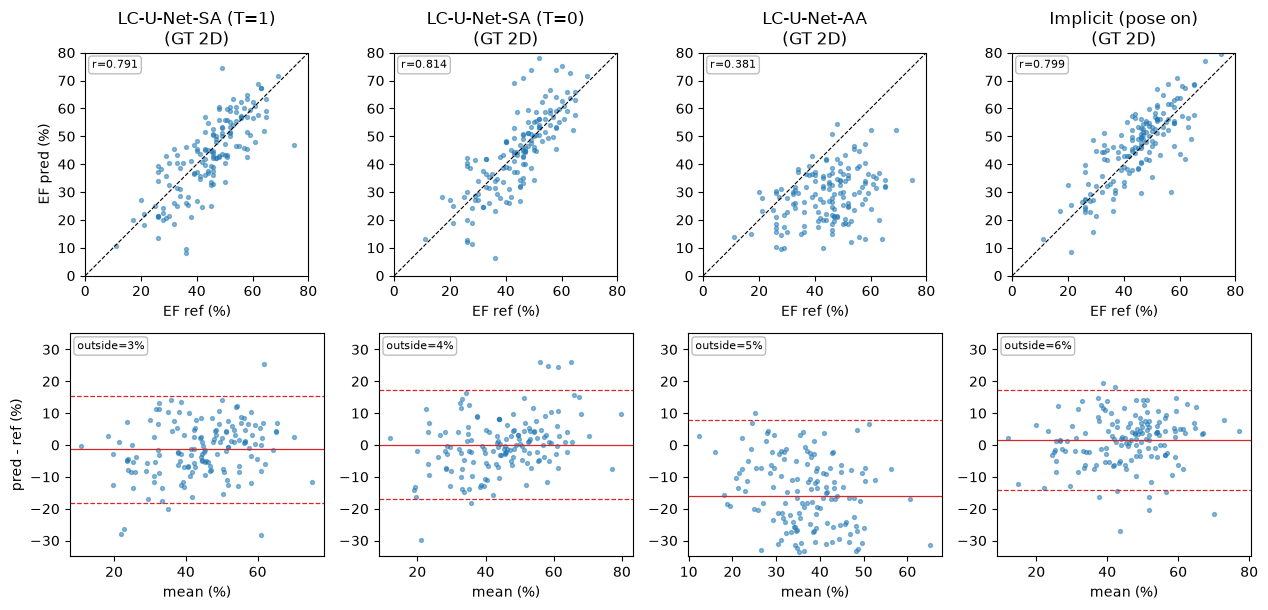

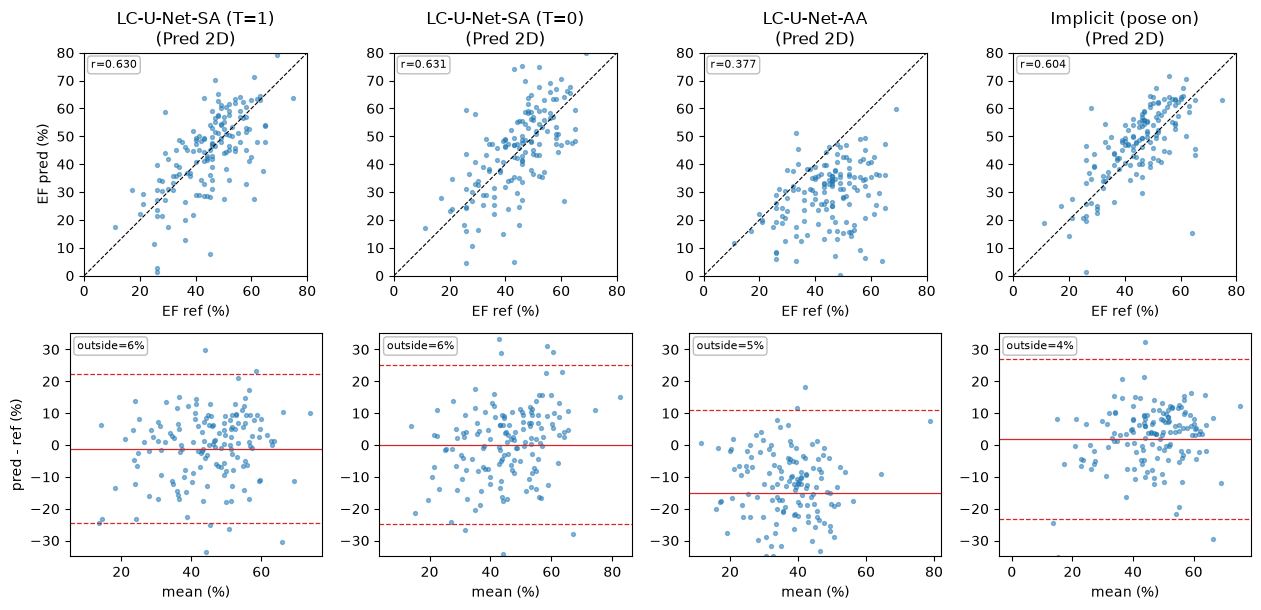

In [ ]:
for labels, sub in df.groupby('labels'):
    rr = [r for r in runs if r in set(sub['run'])]
    fig, axes = plt.subplots(2, len(rr), figsize=(3.2 * len(rr), 6.2),
                             squeeze=False)
    for j, run in enumerate(rr):
        g = sub[sub['run'] == run]
        ax = axes[0, j]
        ax.plot([0, 80], [0, 80], 'k--', lw=0.8)
        ax.scatter(g['ef_ref'], g['ef_median'], s=8, alpha=0.5)
        e = g['ef_err'].to_numpy(float)
        r_p = (stats.pearsonr(g['ef_median'], g['ef_ref'])[0]
               if len(g) > 2 else np.nan)
        ax.text(0.03, 0.97,
                f'r={r_p:.3f}',
                transform=ax.transAxes, va='top', ha='left', fontsize=8,
                bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.85))
        ax.set(title=f'{run}\n({labels})', xlabel='EF ref (%)',
               ylabel='EF pred (%)' if j == 0 else None,
               xlim=(0, 80), ylim=(0, 80))
        ax.set_aspect('equal')
        ax = axes[1, j]
        m = (g['ef_median'] + g['ef_ref']) / 2
        d = g['ef_err']
        mu, sd = d.mean(), d.std(ddof=1)
        ax.scatter(m, d, s=8, alpha=0.5)
        for y, ls in ((mu, '-'), (mu + 1.96 * sd, '--'), (mu - 1.96 * sd, '--')):
            ax.axhline(y, color='C3', ls=ls, lw=0.9)
        out_pct = 100 * np.mean(np.abs(d - mu) > 1.96 * sd)
        ax.text(0.03, 0.97, f'outside={out_pct:.0f}%',
                transform=ax.transAxes, va='top', ha='left', fontsize=8,
                bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.85))
        ax.set(xlabel='mean (%)', ylabel='pred - ref (%)' if j == 0 else None,
               ylim=(-35, 35))
    fig.tight_layout()
plt.show()

LC-U-Net-SA (T=1)/GT 2D: width-|err| Spearman 0.185
LC-U-Net-SA (T=1)/Pred 2D: width-|err| Spearman 0.166


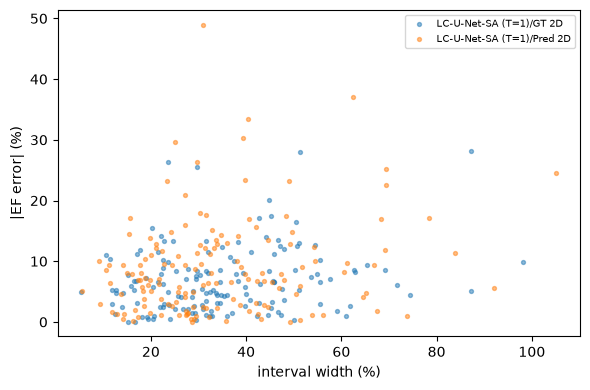

In [ ]:
# F3: 区間較正(サンプリング系のみ): |誤差| vs 幅、および coverage
samp = df[(df['ef_width'] > 0)]
if len(samp):
    fig, axes = plt.subplots(1, 1, figsize=(6, 4))
    for (run, labels), g in samp.groupby(['run', 'labels']):
        axes.scatter(g['ef_width'], g['ef_err'].abs(), s=8, alpha=0.5,
                     label=f'{run}/{labels}')
        rho = stats.spearmanr(g['ef_width'], g['ef_err'].abs())[0]
        print(f'{run}/{labels}: width-|err| Spearman {rho:.3f}')
    axes.set(xlabel='interval width (%)', ylabel='|EF error| (%)')
    axes.legend(fontsize=7)
    fig.tight_layout()
    plt.show()

In [ ]:
# T2: pred / gt 入力の誤差分解(同一 run・同一症例のペア)
GT_L = LABEL_RENAME.get('gt', 'gt')
PRED_L = LABEL_RENAME.get('pred', 'pred')
rows = []
for run in runs:
    g = df[df['run'] == run].pivot_table(index='case', columns='labels',
                                         values='ef_err', aggfunc='first')
    have = sorted(set(g.columns))
    g = g[[GT_L, PRED_L]].dropna()
    rows.append({'run': run, 'n_pair': len(g),
                 f'MAE_{GT_L}': np.abs(g[GT_L]).mean(),
                 f'MAE_{PRED_L}': np.abs(g[PRED_L]).mean(),
                 'ΔMAE (2Dセグ寄与)': np.abs(g[PRED_L]).mean() - np.abs(g[GT_L]).mean(),
                 'err corr': g[GT_L].corr(g[PRED_L])})
if rows:
    print('== T2: 誤差分解 — MAE_gt = 手法固有、ΔMAE = 2D セグ誤差の寄与 ==')
    display(pd.DataFrame(rows).round(2).set_index('run'))
 

== T2: 誤差分解 — MAE_gt = 手法固有、ΔMAE = 2D セグ誤差の寄与 ==


,n_pair,MAE_GT 2D,MAE_Pred 2D,ΔMAE (2Dセグ寄与),err corr
run,,,,,
LC-U-Net-SA (T=1),150,6.83,8.92,2.09,0.52
LC-U-Net-SA (T=0),150,6.49,9.66,3.17,0.47
LC-U-Net-AA,150,16.79,16.14,-0.64,0.65
Implicit (pose on),150,6.43,8.61,2.19,0.21


In [ ]:
# T3: モデル間 |EF 誤差| のペア Wilcoxon + Holm(labels ごと)
for labels, sub in df.groupby('labels'):
    piv = sub.pivot_table(index='case', columns='run', values='ef_err',
                          aggfunc='first')
    pairs = [p for p in itertools.combinations(
        [r for r in runs if r in piv.columns], 2)]
    res = []
    for a, b in pairs:
        d = piv[[a, b]].dropna()
        if len(d) < 5:
            continue
        stat, p = stats.wilcoxon(d[a].abs(), d[b].abs())
        res.append({'A': a, 'B': b, 'n': len(d),
                    'MAE_A': d[a].abs().mean(), 'MAE_B': d[b].abs().mean(),
                    'p_raw': p})
    if res:
        t = pd.DataFrame(res).sort_values('p_raw').reset_index(drop=True)
        m = len(t)
        # Holm step-down: 昇順で p_(i)*(m-i) を取り、max-accumulate で単調化
        t['p_holm'] = np.maximum.accumulate(t['p_raw'] * (m - t.index)).clip(upper=1)
        print(f'== T3: paired Wilcoxon on |EF err| — input: {labels} ==')
        display(t.round(4))

== T3: paired Wilcoxon on |EF err| — input: GT 2D ==


,A,B,n,MAE_A,MAE_B,p_raw,p_holm
0,LC-U-Net-AA,Implicit (pose on),150,16.7850,6.4262,0.0000,0.0000
1,LC-U-Net-SA (T=1),LC-U-Net-AA,150,6.8343,16.7850,0.0000,0.0000
2,LC-U-Net-SA (T=0),LC-U-Net-AA,150,6.4865,16.7850,0.0000,0.0000
3,LC-U-Net-SA (T=1),LC-U-Net-SA (T=0),150,6.8343,6.4865,0.1351,0.4052
4,LC-U-Net-SA (T=0),Implicit (pose on),150,6.4865,6.4262,0.7363,1.0000
5,LC-U-Net-SA (T=1),Implicit (pose on),150,6.8343,6.4262,0.9559,1.0000


== T3: paired Wilcoxon on |EF err| — input: Pred 2D ==


,A,B,n,MAE_A,MAE_B,p_raw,p_holm
0,LC-U-Net-AA,Implicit (pose on),150,16.1443,8.6126,0.0000,0.0000
1,LC-U-Net-SA (T=1),LC-U-Net-AA,150,8.9205,16.1443,0.0000,0.0000
2,LC-U-Net-SA (T=0),LC-U-Net-AA,150,9.6578,16.1443,0.0000,0.0000
3,LC-U-Net-SA (T=0),Implicit (pose on),150,9.6578,8.6126,0.0299,0.0896
4,LC-U-Net-SA (T=1),LC-U-Net-SA (T=0),150,8.9205,9.6578,0.2091,0.4181
5,LC-U-Net-SA (T=1),Implicit (pose on),150,8.9205,8.6126,0.4695,0.4695


In [100]:
JSONL_PATHS = {                      # 表示ラベル -> jsonl パス
    'LC-I-Net-SA':  '../results/recon/camus/camus_C_seq.jsonl',
    'LC-I-Net-AA':     '../results/recon/camus/camus_A2c_seq.jsonl',
}
ARM_COLORS  = {'LC-I-Net-AA': 'tab:blue', 'LC-I-Net-SA': 'tab:orange'}
N_PHASE     = 21                     # 共通位相グリッド点数 (0=ED端, 1=ES端)
MIN_FRAMES  = 4                      # これ未満しか有効フレームが無い症例は除外
MONO_TOL    = 0.005                  # 単調性違反の許容 (正規化体積の増分がこれ超で違反)
OUT_DIR     = 'results/recon/seq_analysis'
os.makedirs(OUT_DIR, exist_ok=True)
PHASE = np.linspace(0.0, 1.0, N_PHASE)

In [101]:
# ======================= load =======================
def load_jsonl(path):
    frames, cases = [], []
    with open(path) as f:
        for line in f:
            r = json.loads(line)
            if r.get('kind') == 'frame' and r.get('status') == 'ok':
                frames.append(r)
            elif r.get('kind') == 'case':
                cases.append(r)
    return pd.DataFrame(frames), pd.DataFrame(cases)

frames_df, cases_df = [], []
for arm, path in JSONL_PATHS.items():
    fdf, cdf = load_jsonl(path)
    fdf['arm'] = arm; cdf['arm'] = arm
    frames_df.append(fdf); cases_df.append(cdf)
frames_df = pd.concat(frames_df, ignore_index=True)
cases_df  = pd.concat(cases_df,  ignore_index=True)

print(frames_df.groupby('arm').agg(n_frames=('case','size'), n_cases=('case','nunique')))
cases_df.groupby('arm')[['ef','r_vol_area']].describe().round(2)

             n_frames  n_cases
arm                           
LC-I-Net-AA      3100      150
LC-I-Net-SA      3100      150


ef                                                 r_vol_area  \
             count   mean    std   min    25%    50%    75%    max      count   
arm                                                                             
LC-I-Net-AA  150.0  28.69   9.52  9.16  21.23  28.58  35.72  54.09      150.0   
LC-I-Net-SA  150.0  44.14  15.65  5.21  34.03  43.91  55.15  86.58      150.0   

                                                      
             mean   std   min   25%   50%   75%  max  
arm                                                   
LC-I-Net-AA  0.97  0.09 -0.01  0.97  0.98  0.99  1.0  
LC-I-Net-SA  0.96  0.18 -0.62  0.98  0.99  1.00  1.0

In [102]:
# ============== per-case curves (draw方向は中央値で潰す) ==============
def case_curve(g):
    """1症例分の frame 行 -> (frame_frac, V_LV) 中央値曲線 (draw方向 median)"""
    m = (g.groupby('frame')
           .agg(frac=('frame_frac', 'first'), v=('vol_LV_ml', 'median'))
           .sort_values('frac'))
    return m['frac'].to_numpy(), m['v'].to_numpy()

curves = {}          # (arm, case) -> dict
for (arm, case), g in frames_df.groupby(['arm', 'case']):
    frac, v = case_curve(g)
    ok = np.isfinite(v)
    if ok.sum() < MIN_FRAMES:
        continue
    frac, v = frac[ok], v[ok]
    edv = v.max()
    if edv <= 0:
        continue
    vn = v / edv                                  # 正規化: 終端 = 1 - EF/100
    vn_phase = np.interp(PHASE, frac, vn)          # 共通位相グリッドへ
    d2 = np.diff(vn, 2)                            # ネイティブグリッドで二階差分
    curves[(arm, case)] = dict(
        vn_phase=vn_phase, edv=edv,
        jitter=float(np.sqrt(np.mean(d2**2))) if len(d2) else np.nan,
        mono_viol=float(np.mean(np.diff(vn) > MONO_TOL)) if len(vn) > 1 else np.nan)

print(f"usable curves: " + ", ".join(
    f"{arm}: {sum(1 for a,_ in curves if a==arm)}" for arm in JSONL_PATHS))

usable curves: LC-I-Net-SA: 150, LC-I-Net-AA: 150


<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:12: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_180376/1963921108.py:12: SyntaxWarning: invalid escape sequence '\;'
  ax.set_ylabel('$V_{LV}(t)\;/\;EDV$')


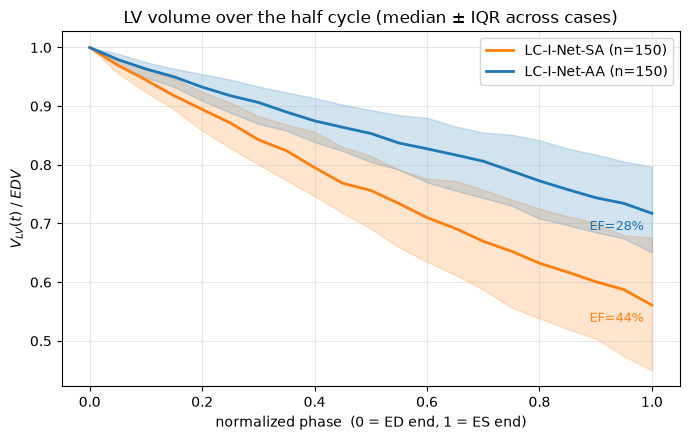

In [103]:
# ============== 1) 正規化体積-位相曲線バンド ==============
fig, ax = plt.subplots(figsize=(7, 4.5))
for arm in JSONL_PATHS:
    M = np.stack([c['vn_phase'] for (a, _), c in curves.items() if a == arm])
    med = np.median(M, 0); lo = np.percentile(M, 25, 0); hi = np.percentile(M, 75, 0)
    col = ARM_COLORS.get(arm)
    ax.plot(PHASE, med, color=col, lw=2, label=f"{arm} (n={len(M)})")
    ax.fill_between(PHASE, lo, hi, color=col, alpha=0.20)
    ax.annotate(f"EF={100*(1-med[-1]):.0f}%", (1.0, med[-1]),
                xytext=(-6, -12), textcoords='offset points', color=col, fontsize=9, ha='right')
ax.set_xlabel('normalized phase  (0 = ED end, 1 = ES end)')
ax.set_ylabel('$V_{LV}(t)\;/\;EDV$')
ax.set_title('LV volume over the half cycle (median ± IQR across cases)')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/curve_bands.png', dpi=180)
plt.show()

In [104]:
# ============== 2) 時間的一貫性の集計表 ==============
rows = []
for arm in JSONL_PATHS:
    cj = [c for (a, _), c in curves.items() if a == arm]
    cd = cases_df[cases_df.arm == arm]
    jit = np.array([c['jitter'] for c in cj]); mv = np.array([c['mono_viol'] for c in cj])
    rows.append(dict(
        arm=arm, n=len(cj),
        jitter_med=np.nanmedian(jit), jitter_iqr=np.nanpercentile(jit,75)-np.nanpercentile(jit,25),
        mono_violation_rate=np.nanmean(mv),
        ends_consistent_rate=cd['ends_consistent'].mean() if 'ends_consistent' in cd else np.nan,
        r_vol_area_med=cd['r_vol_area'].median() if 'r_vol_area' in cd else np.nan,
        ef_med=cd['ef'].median(), edv_med=cd['edv_ml'].median() if 'edv_ml' in cd else np.nan))
consistency = pd.DataFrame(rows).set_index('arm').round(4)
consistency.to_csv(f'{OUT_DIR}/consistency_table.csv')
consistency

,n,jitter_med,jitter_iqr,mono_violation_rate,ends_consistent_rate,r_vol_area_med,ef_med,edv_med
arm,,,,,,,,
LC-I-Net-SA,150,0.0260,0.0169,0.0844,0.96,0.9920,43.9100,112.312
LC-I-Net-AA,150,0.0233,0.0116,0.1256,0.96,0.9838,28.5837,120.868


<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:25: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_180376/1310242057.py:25: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('frame-to-frame RMS of $\hat{z}$')


LC-I-Net-AA: z ≡ 0 (zero placement) — skip


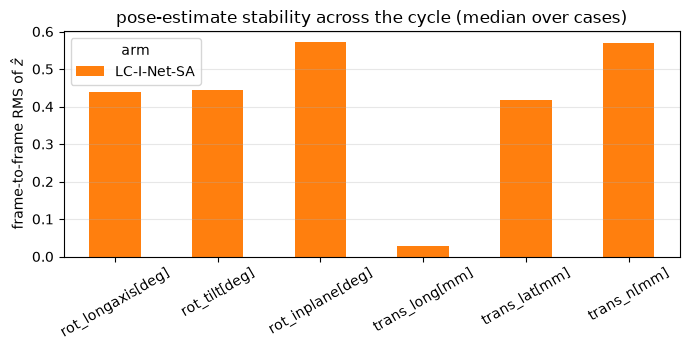

,rot_longaxis[deg],rot_tilt[deg],rot_inplane[deg],trans_long[mm],trans_lat[mm],trans_n[mm]
arm,,,,,,
LC-I-Net-SA,0.44,0.444,0.572,0.029,0.417,0.569


In [106]:
# ============== 4) z 推定のフレーム間安定性 (posteriorのみ意味を持つ) ==============
Z_NAMES = ['rot_longaxis[deg]', 'rot_tilt[deg]', 'rot_inplane[deg]',
           'trans_long[mm]', 'trans_lat[mm]', 'trans_n[mm]']
zst = []
for arm in JSONL_PATHS:
    fa = frames_df[(frames_df.arm == arm) & frames_df['z'].notna()]
    if not len(fa):
        continue
    Z = np.stack(fa['z'].to_numpy())            # [rows, 6] (A2C残差)
    if np.abs(Z).max() < 1e-9:
        print(f"{arm}: z ≡ 0 (zero placement) — skip"); continue
    for case, g in fa.groupby('case'):
        gg = g[g.get('sample_idx', 0) == 0].sort_values('frame')
        Zc = np.stack(gg['z'].to_numpy())
        if len(Zc) < 3:
            continue
        dz = np.diff(Zc, axis=0)                 # フレーム間の推定 z の変化
        zst.append(dict(arm=arm, case=case,
                        **{n: float(np.sqrt(np.mean(dz[:, k]**2))) for k, n in enumerate(Z_NAMES)}))
if zst:
    zdf = pd.DataFrame(zst)
    zsum = zdf.groupby('arm')[Z_NAMES].median().round(3)
    zsum.to_csv(f'{OUT_DIR}/z_stability.csv')
    ax = zsum.T.plot.bar(figsize=(7, 3.6), rot=30, color=[ARM_COLORS.get(a) for a in zsum.index])
    ax.set_ylabel('frame-to-frame RMS of $\hat{z}$')
    ax.set_title('pose-estimate stability across the cycle (median over cases)')
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.savefig(f'{OUT_DIR}/z_stability.png', dpi=180); plt.show()
    display(zsum)
else:
    print('z が動く arm がありません (posterior run が入っているか確認)')

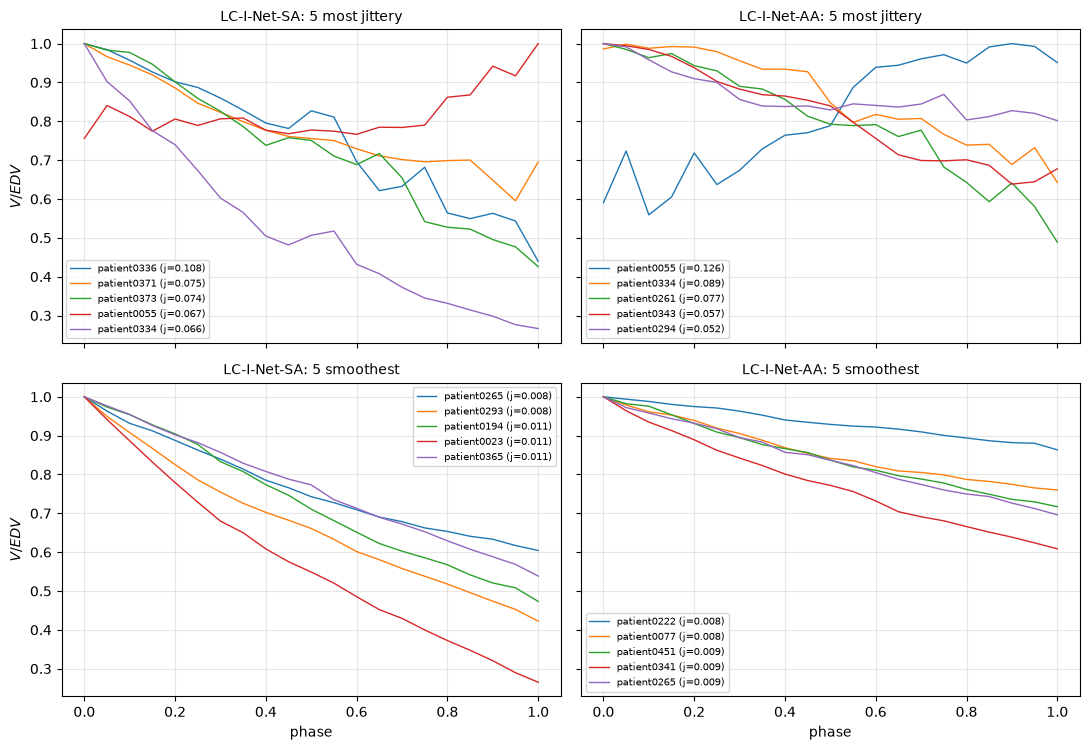

saved to results/recon/seq_analysis


In [108]:
# ============== おまけ: 個別症例の曲線 (ジッター上位5 / 下位5) ==============
n_arms = len(JSONL_PATHS)
fig, axes = plt.subplots(2, n_arms, figsize=(5.5*n_arms, 7.6),
                         sharex=True, sharey=True, squeeze=False)
for col, arm in enumerate(JSONL_PATHS):
    items = [(c, d) for (a, c), d in curves.items() if a == arm]
    jits = np.array([d['jitter'] for _, d in items])
    order = np.argsort(-jits)                        # ジッター降順
    for row, (idx, label) in enumerate([(order[:5],  '5 most jittery'),
                                        (order[-5:][::-1], '5 smoothest')]):
        ax = axes[row][col]
        for k in idx:
            case, d = items[k]
            ax.plot(PHASE, d['vn_phase'], lw=1, label=f"{case} (j={jits[k]:.3f})")
        ax.set_title(f"{arm}: {label}", fontsize=10)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        if row == 1:
            ax.set_xlabel('phase')
        if col == 0:
            ax.set_ylabel('$V/EDV$')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/jitter_extremes.png', dpi=180); plt.show()
print('saved to', OUT_DIR)